Frequência do sinal ajustada para: 99.61 Hz (bin 102)
--- Verificação ---
Amplitude A do sinal: 0.1976
Potência esperada do sinal no bin (A^2/2): 1.95e-02
Potência esperada do ruído por bin (2*sigma_n_sq/NFFT): 1.95e-03
SNR por bin alvo: 10.00 dB (Linear: 10.00)
Potência medida do sinal no bin 102 (freq 99.61 Hz): 1.17e-02
Potência média medida do ruído em bins adjacentes: 1.63e-03
SNR por bin medida: 8.55 dB (Linear: 7.17)


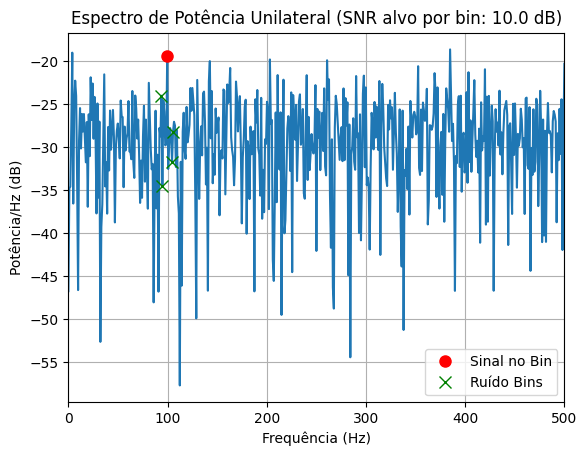

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parâmetros ---
FS = 1000  # Taxa de amostragem (Hz)
NFFT = 1024 # Número de pontos da FFT (e duração da janela de análise)
duration = NFFT / FS  # Duração do sinal em segundos
t = np.arange(NFFT) / FS  # Vetor de tempo

f_signal = 100  # Frequência do sinal (Hz)
# Para garantir que o sinal caia em um bin exato
signal_bin_ideal_idx = int(round(f_signal * NFFT / FS))
f_signal = signal_bin_ideal_idx * FS / NFFT
print(f'Frequência do sinal ajustada para: {f_signal:.2f} Hz (bin {signal_bin_ideal_idx})')

target_snr_db_per_bin = 10  # SNR desejada no bin do sinal (dB)
target_snr_linear_per_bin = 10**(target_snr_db_per_bin / 10)

# --- Geração de Sinal e Ruído ---

# 1. Fixar variância do ruído no tempo
sigma_n_sq = 1.0  # Variância do ruído no tempo (potência do ruído no tempo)
std_n = np.sqrt(sigma_n_sq)

# 2. Potência de ruído esperada por bin (não DC, não Nyquist) na FFT
# P_n_bin_expected = (2/NFFT) * sigma_n_sq
P_n_bin_expected = (2.0 / NFFT) * sigma_n_sq

# 3. Potência de sinal necessária no bin do sinal
P_s_bin_target = target_snr_linear_per_bin * P_n_bin_expected

# 4. Amplitude A da senoide para atingir P_s_bin_target
# P_s_bin_target = A^2 / 2
A_signal = np.sqrt(2 * P_s_bin_target)

# 5. Gerar componentes
s_t = A_signal * np.sin(2 * np.pi * f_signal * t)
n_t = std_n * np.random.randn(NFFT)  # Ruído gaussiano com std_n
x_t = s_t + n_t  # Sinal com ruído

# --- Análise e Verificação ---
X_k = np.fft.fft(x_t)
S_k = np.fft.fft(s_t) # FFT do sinal puro para referência
N_k = np.fft.fft(n_t) # FFT do ruído puro para referência

# Frequências para o espectro unilateral
freq_axis = np.fft.rfftfreq(NFFT, d=1./FS) # Pega apenas o lado positivo
num_freq_bins_onesided = len(freq_axis)

# Potência nos bins (usando a fórmula (2/NFFT^2)*|X(k)|^2 para unilateral)
# np.fft.rfft já lida com o fator 2 implicitamente em certa medida, mas precisamos ser cuidadosos com a escala de potência.
# Se X_k_r = rfft(x_t), então |X_k_r|^2 / (NFFT*FS) é uma estimativa de PSD.
# Potência no bin = PSD * df = PSD * (FS/NFFT) = |X_k_r|^2 / NFFT^2
# Para rfft: DC e Nyquist (se NFFT par) não são dobrados, outros são.
# Para manter a fórmula (2/N^2)|X(k)|^2 consistente com o espectro completo:
X_k_onesided_scaled = X_k[:num_freq_bins_onesided] # Usando o espectro completo e fatiando
power_X_k_onesided = (2 / NFFT**2) * np.abs(X_k_onesided_scaled)**2
power_X_k_onesided[0] = (1 / NFFT**2) * np.abs(X_k_onesided_scaled[0])**2 # DC
if NFFT % 2 == 0: # Nyquist, se NFFT for par
    power_X_k_onesided[-1] = (1 / NFFT**2) * np.abs(X_k_onesided_scaled[-1])**2

# O índice do bin do sinal em freq_axis (que vem de rfftfreq ou do fatiamento do fft completo)
actual_signal_bin_fft_idx = signal_bin_ideal_idx # Se f_signal > 0

measured_signal_power_in_bin = power_X_k_onesided[actual_signal_bin_fft_idx]

# Estimar potência de ruído nos bins adjacentes
noise_bins_for_avg_indices = []
if actual_signal_bin_fft_idx + 5 < num_freq_bins_onesided: noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx + 5)
if actual_signal_bin_fft_idx + 6 < num_freq_bins_onesided: noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx + 6)
if actual_signal_bin_fft_idx - 5 > 0: noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx - 5)
if actual_signal_bin_fft_idx - 6 > 0: noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx - 6)

if not noise_bins_for_avg_indices: # Fallback simples
    if actual_signal_bin_fft_idx + 2 < num_freq_bins_onesided:
        noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx + 2)
    elif actual_signal_bin_fft_idx - 2 > 0:
        noise_bins_for_avg_indices.append(actual_signal_bin_fft_idx - 2)

if noise_bins_for_avg_indices:
    measured_noise_power_around_signal = np.mean(power_X_k_onesided[noise_bins_for_avg_indices])
else:
    measured_noise_power_around_signal = np.nan # Não foi possível encontrar bins de ruído
    print("Aviso: Não foi possível encontrar bins de ruído adjacentes válidos.")


# SNR por bin medida
if not np.isnan(measured_noise_power_around_signal) and measured_noise_power_around_signal > 0:
    measured_snr_per_bin = measured_signal_power_in_bin / measured_noise_power_around_signal
    measured_snr_db_per_bin = 10 * np.log10(measured_snr_per_bin)
else:
    measured_snr_per_bin = np.nan
    measured_snr_db_per_bin = np.nan

print('--- Verificação ---')
print(f'Amplitude A do sinal: {A_signal:.4f}')
print(f'Potência esperada do sinal no bin (A^2/2): {A_signal**2/2:.2e}')
print(f'Potência esperada do ruído por bin (2*sigma_n_sq/NFFT): {P_n_bin_expected:.2e}')
print(f'SNR por bin alvo: {target_snr_db_per_bin:.2f} dB (Linear: {target_snr_linear_per_bin:.2f})')
print(f'Potência medida do sinal no bin {actual_signal_bin_fft_idx} (freq {freq_axis[actual_signal_bin_fft_idx]:.2f} Hz): {measured_signal_power_in_bin:.2e}')
print(f'Potência média medida do ruído em bins adjacentes: {measured_noise_power_around_signal:.2e}')
print(f'SNR por bin medida: {measured_snr_db_per_bin:.2f} dB (Linear: {measured_snr_per_bin:.2f})')

# Plot
plt.figure()
plt.plot(freq_axis, 10 * np.log10(power_X_k_onesided + np.finfo(float).eps))
plt.plot(freq_axis[actual_signal_bin_fft_idx], 10 * np.log10(measured_signal_power_in_bin + np.finfo(float).eps),
         'ro', markersize=8, label='Sinal no Bin')
if noise_bins_for_avg_indices:
    plt.plot(freq_axis[noise_bins_for_avg_indices],
             10 * np.log10(power_X_k_onesided[noise_bins_for_avg_indices] + np.finfo(float).eps),
             'gx', markersize=8, label='Ruído Bins')
plt.title(f'Espectro de Potência Unilateral (SNR alvo por bin: {target_snr_db_per_bin:.1f} dB)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Potência/Hz (dB)')
plt.legend()
plt.grid(True)
plt.xlim([0, FS / 2])
plt.show()